In [4]:
import pandas as pd

df = pd.read_csv(
    "2019-Oct.csv",
    nrows=3000000
)

df.head()
df.describe()
df.isnull().sum()
df["event_type"].value_counts()

df["event_time"] = pd.to_datetime(df["event_time"])

df.info()

df.to_csv("new_file.csv", index=False)

<class 'pandas.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 9 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[us, UTC]
 1   event_type     str                
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  str                
 5   brand          str                
 6   price          float64            
 7   user_id        int64              
 8   user_session   str                
dtypes: datetime64[us, UTC](1), float64(1), int64(3), str(4)
memory usage: 380.1 MB


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "new_file.csv"
)

df.head()
print(df.shape)
print(df.info())

df.isnull().sum()
df.describe()
df["event_type"].value_counts()

(3000000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 451.6 MB
None


event_type
view        2904210
purchase      50802
cart          44988
Name: count, dtype: int64

In [2]:
import pandas as pd


df = pd.read_csv("new_file.csv", nrows=3000000)
df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")


print(df.isnull().sum())
df = df.dropna(subset=["event_time"]) 


print(df.dtypes)


df["price"] = df["price"].astype(float)
df["user_id"] = df["user_id"].astype(int)
df["category_id"] = df["category_id"].astype(int)

event_time            0
event_type            0
product_id            0
category_id           0
category_code    943490
brand            439487
price                 0
user_id               0
user_session          0
dtype: int64
event_time       datetime64[us, UTC]
event_type                       str
product_id                     int64
category_id                    int64
category_code                    str
brand                            str
price                        float64
user_id                        int64
user_session                     str
dtype: object


      Stage  Conversion
0      View    0.999915
1      Cart    0.052563
2  Purchase    0.081542


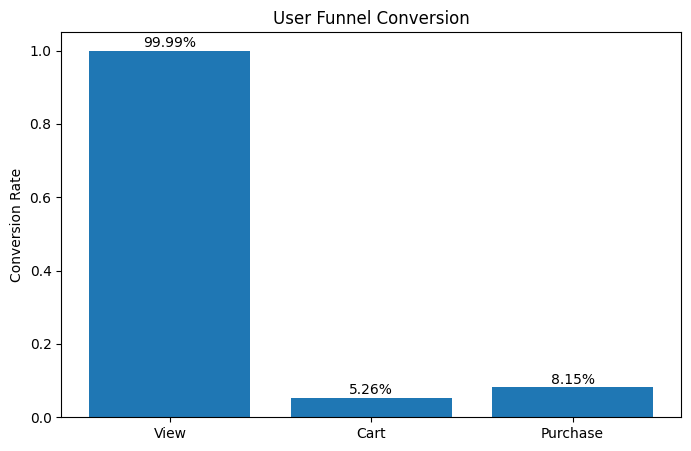

In [5]:
# 2. Funnel Analysis
import pandas as pd
import numpy as np

user_behavior = df.groupby("user_id")["event_type"].apply(list).reset_index()

user_behavior["viewed"] = user_behavior["event_type"].apply(lambda x: 1 if "view" in x else 0)
user_behavior["carted"] = user_behavior["event_type"].apply(lambda x: 1 if "cart" in x else 0)
user_behavior["purchased"] = user_behavior["event_type"].apply(lambda x: 1 if "purchase" in x else 0)


total_users = len(user_behavior)
view_rate = user_behavior["viewed"].sum() / total_users
cart_rate = user_behavior["carted"].sum() / total_users
purchase_rate = user_behavior["purchased"].sum() / total_users

funnel_df = pd.DataFrame({
    "Stage": ["View", "Cart", "Purchase"],
    "Conversion": [view_rate, cart_rate, purchase_rate]
})
print(funnel_df)


import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    funnel_df["Stage"],
    funnel_df["Conversion"]
)

plt.title("User Funnel Conversion")
plt.ylabel("Conversion Rate")

for i,v in enumerate(funnel_df["Conversion"]):
    plt.text(
        i,
        v+0.01,
        f"{v:.2%}",
        ha="center"
    )

plt.show()

segment
Medium Value    16300
High Value       9015
Low Value        8167
Name: count, dtype: int64


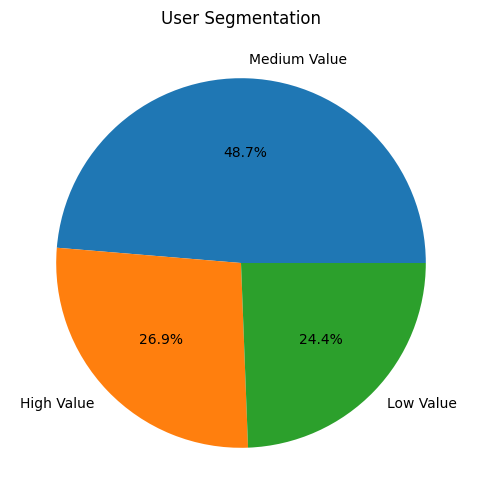

In [6]:
# 3. User Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

user_spend = df[df["event_type"]=="purchase"].groupby("user_id")["price"].sum().reset_index()
user_spend["segment"] = pd.cut(user_spend["price"],
                               bins=[-np.inf, 100, 500, np.inf],
                               labels=["Low Value", "Medium Value", "High Value"])
segment_counts = user_spend["segment"].value_counts()
print(segment_counts)

segment_counts = (
    user_spend["segment"]
    .value_counts()
)

plt.figure(figsize=(6,6))

segment_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title(
    "User Segmentation"
)

plt.show()

(3000000, 9)
                       date  day1_retention
0 2019-10-01 00:00:00+00:00        0.172787
1 2019-10-02 00:00:00+00:00        0.089735
2 2019-10-03 00:00:00+00:00        0.000000


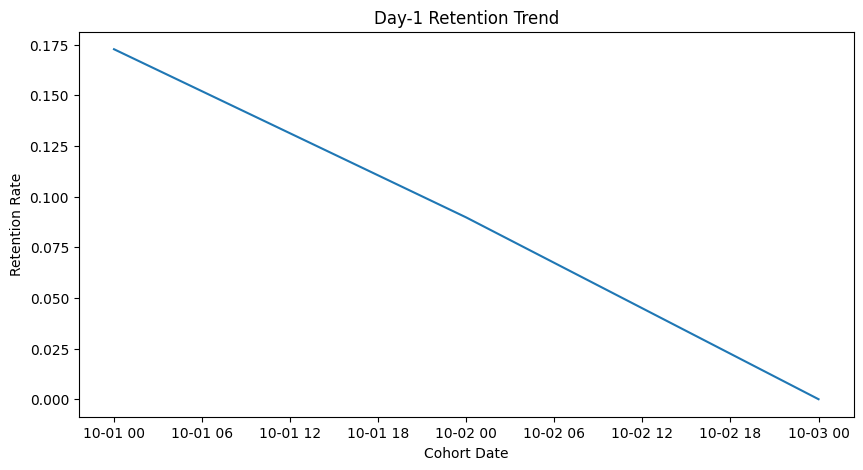

In [8]:
##4.Retention Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "new_file.csv"
)

df["event_time"] = pd.to_datetime(df["event_time"])

print(df.shape)

df["event_date"] = pd.to_datetime(
    df["event_time"]
).dt.normalize()

first_event = (
    df.groupby("user_id")["event_date"]
    .min()
    .reset_index()
)

first_event.columns = [
    "user_id",
    "first_event_date"
]

df_retention = df.merge(
    first_event,
    on="user_id",
    how="left"
)

df_retention["days_since_first"] = (
    df_retention["event_date"]
    -
    df_retention["first_event_date"]
).dt.days


day0_users = (
    df_retention[
        df_retention["days_since_first"] == 0
    ]
    .groupby("first_event_date")["user_id"]
    .nunique()
)

day1_users = (
    df_retention[
        df_retention["days_since_first"] == 1
    ]
    .groupby("first_event_date")["user_id"]
    .nunique()
)

retention_rate = (
    day1_users / day0_users
).fillna(0)

retention_df = pd.DataFrame({
    "date": retention_rate.index,
    "day1_retention": retention_rate.values
})

print(retention_df.head())

plt.figure(figsize=(10,5))

plt.plot(
    retention_df["date"],
    retention_df["day1_retention"]
)

plt.title(
    "Day-1 Retention Trend"
)

plt.ylabel(
    "Retention Rate"
)

plt.xlabel(
    "Cohort Date"
)

plt.show()
